In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.preprocessing import StandardScaler

from sklearn.dummy import DummyClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)

In [2]:
df = pd.read_csv("data.csv")

print(df.head())
print(df.info())
print(df.describe())



         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

In [3]:
if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)

if 'Unnamed: 32' in df.columns:
    df.drop('Unnamed: 32', axis=1, inplace=True)

# Convert diagnosis to numeric

df['diagnosis'] = df['diagnosis'].map({
    'M':1,
    'B':0
})

In [4]:
print("\nMissing Values:")
print(df.isnull().sum())



Missing Values:
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


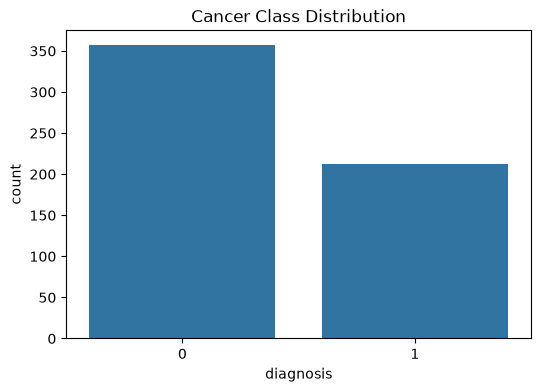

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x='diagnosis', data=df)
plt.title("Cancer Class Distribution")
plt.show()

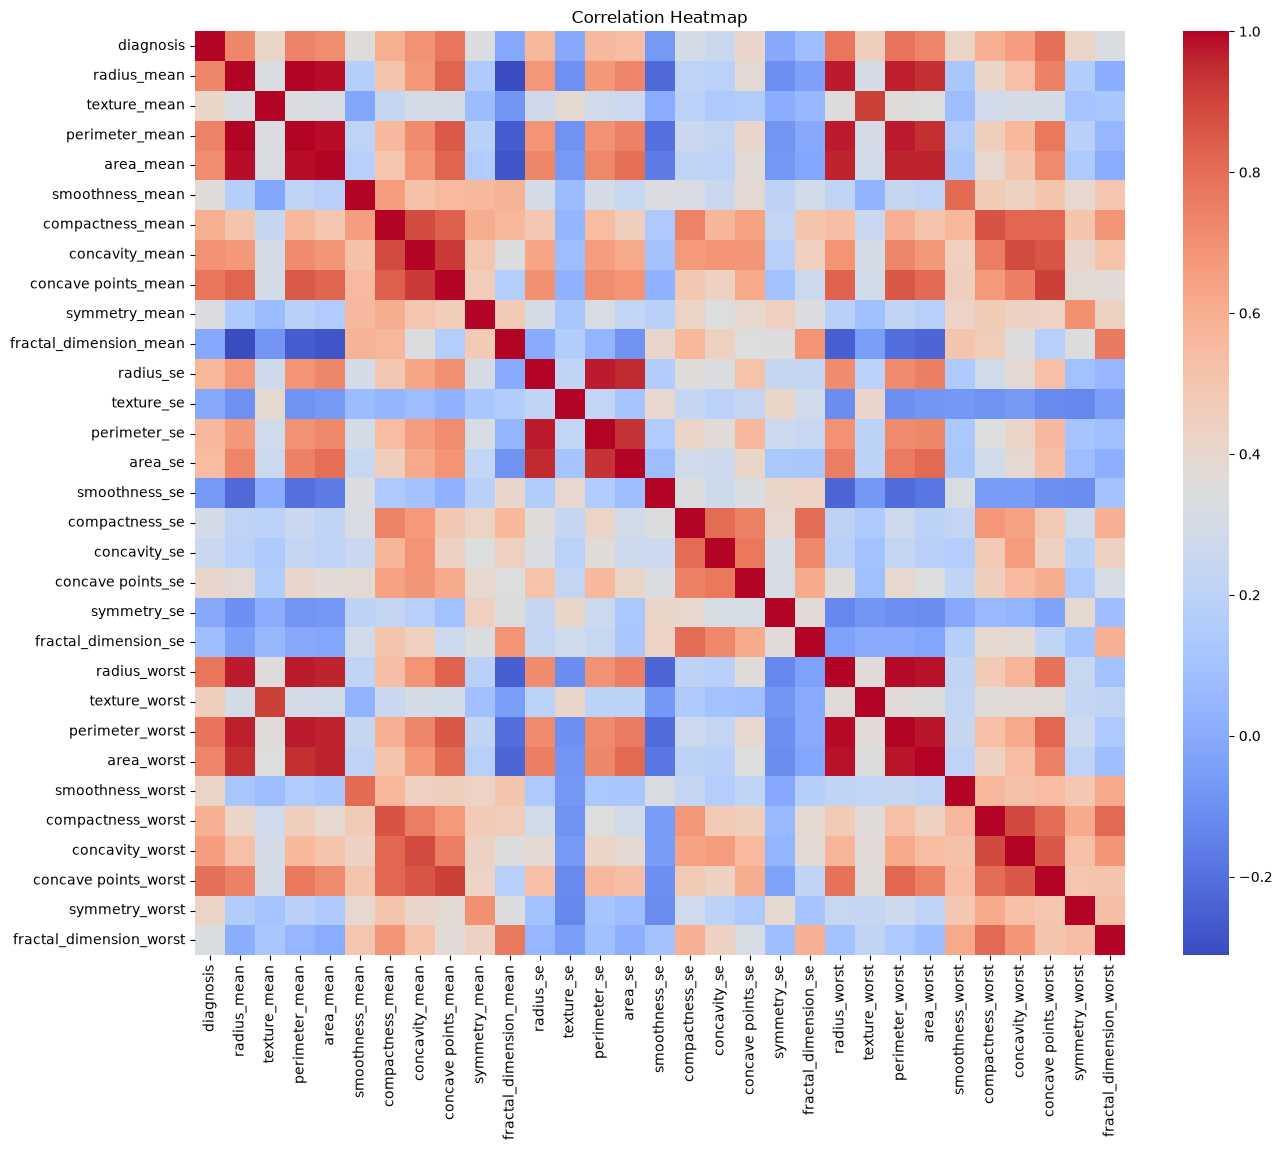

In [6]:
plt.figure(figsize=(15,12))
sns.heatmap(
    df.corr(),
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

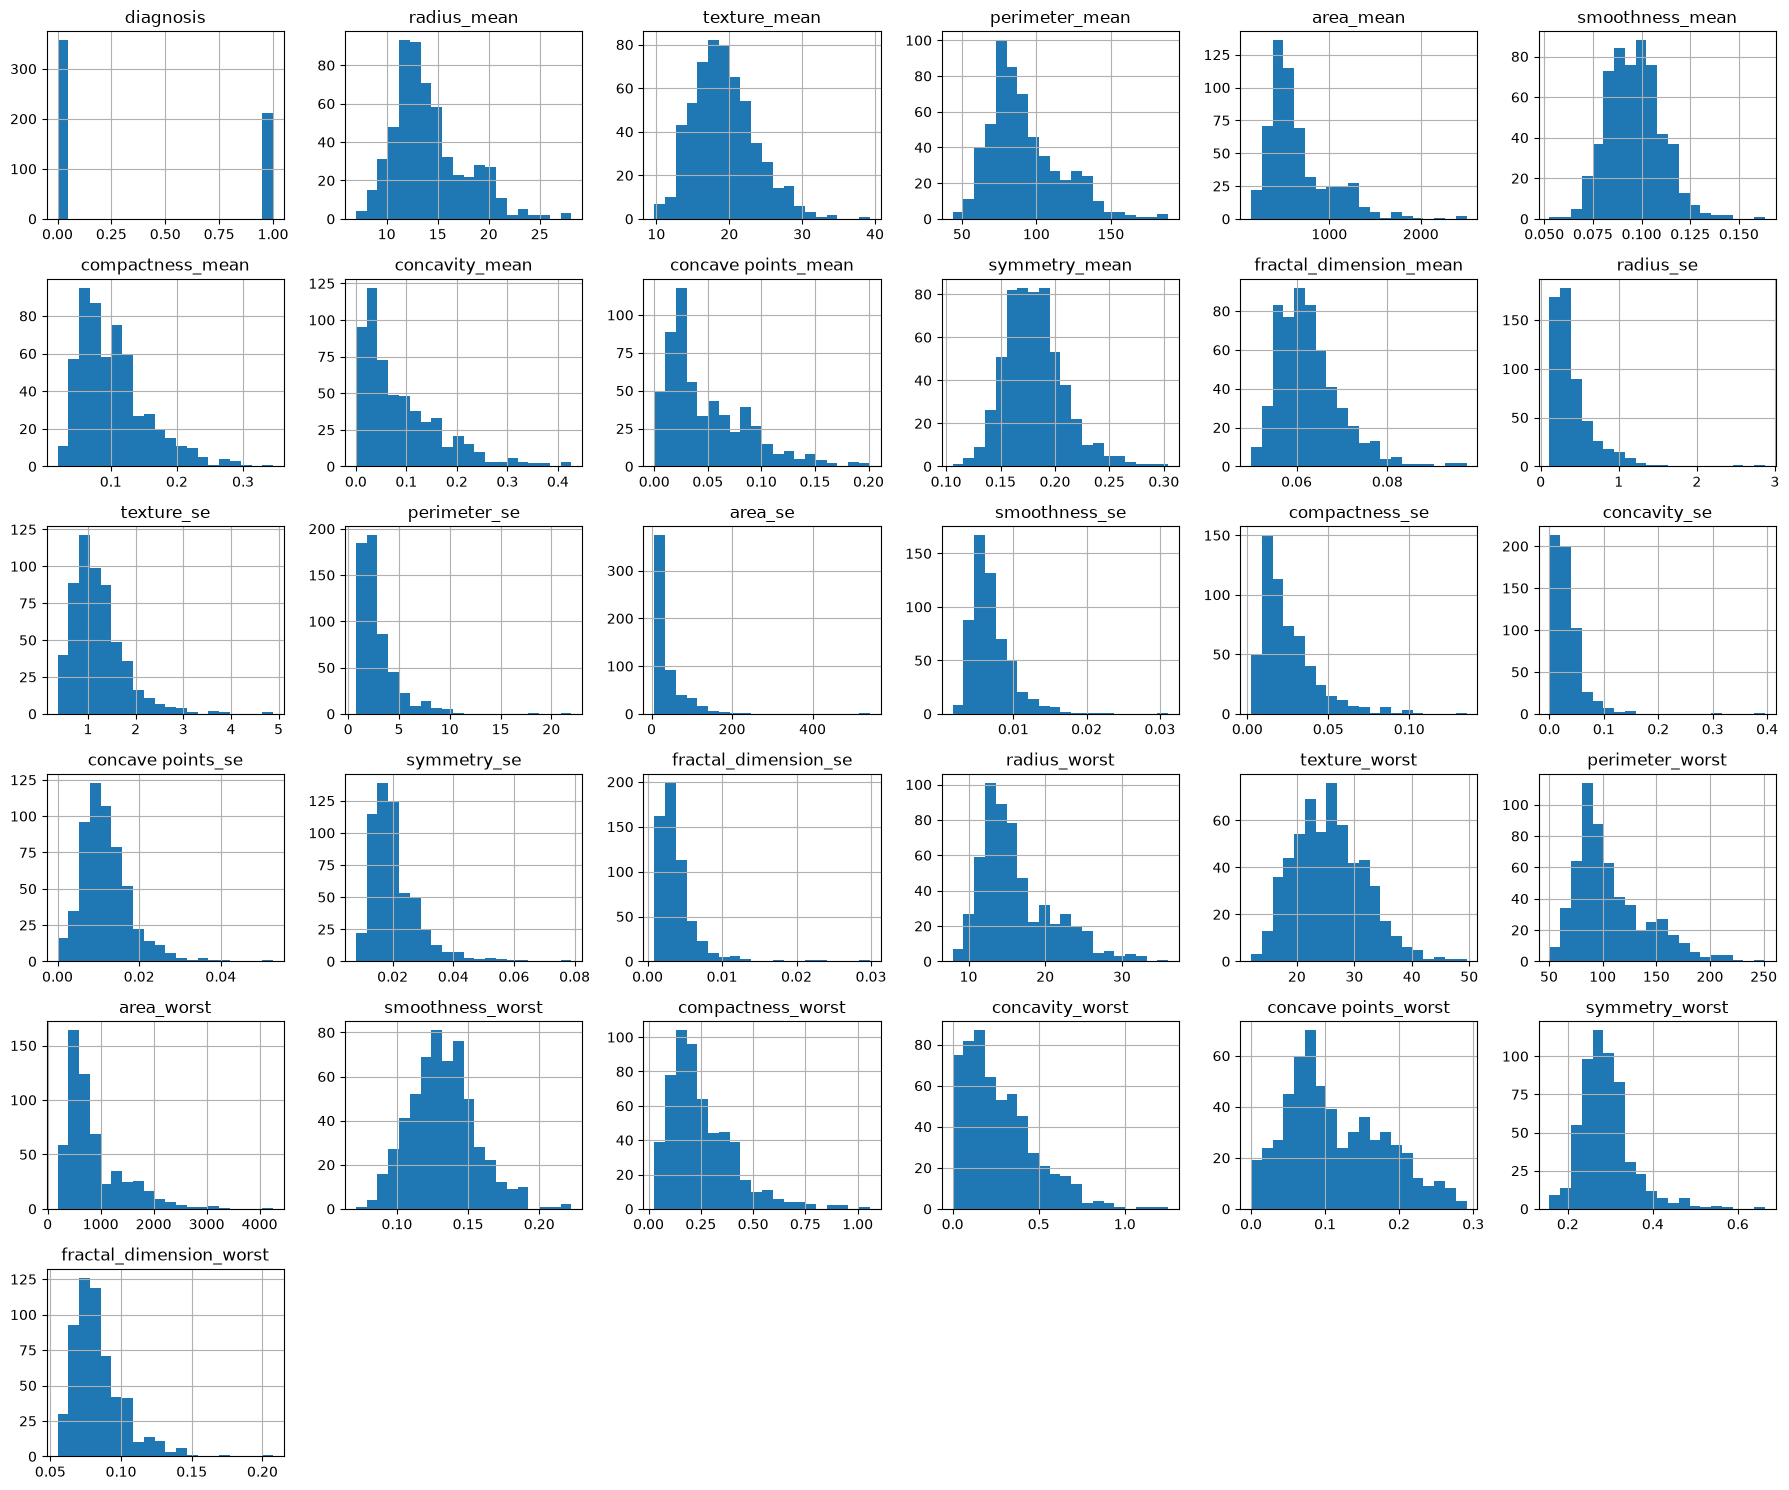

In [7]:
df.hist(
    figsize=(18,15),
    bins=20
)

plt.tight_layout()
plt.show()

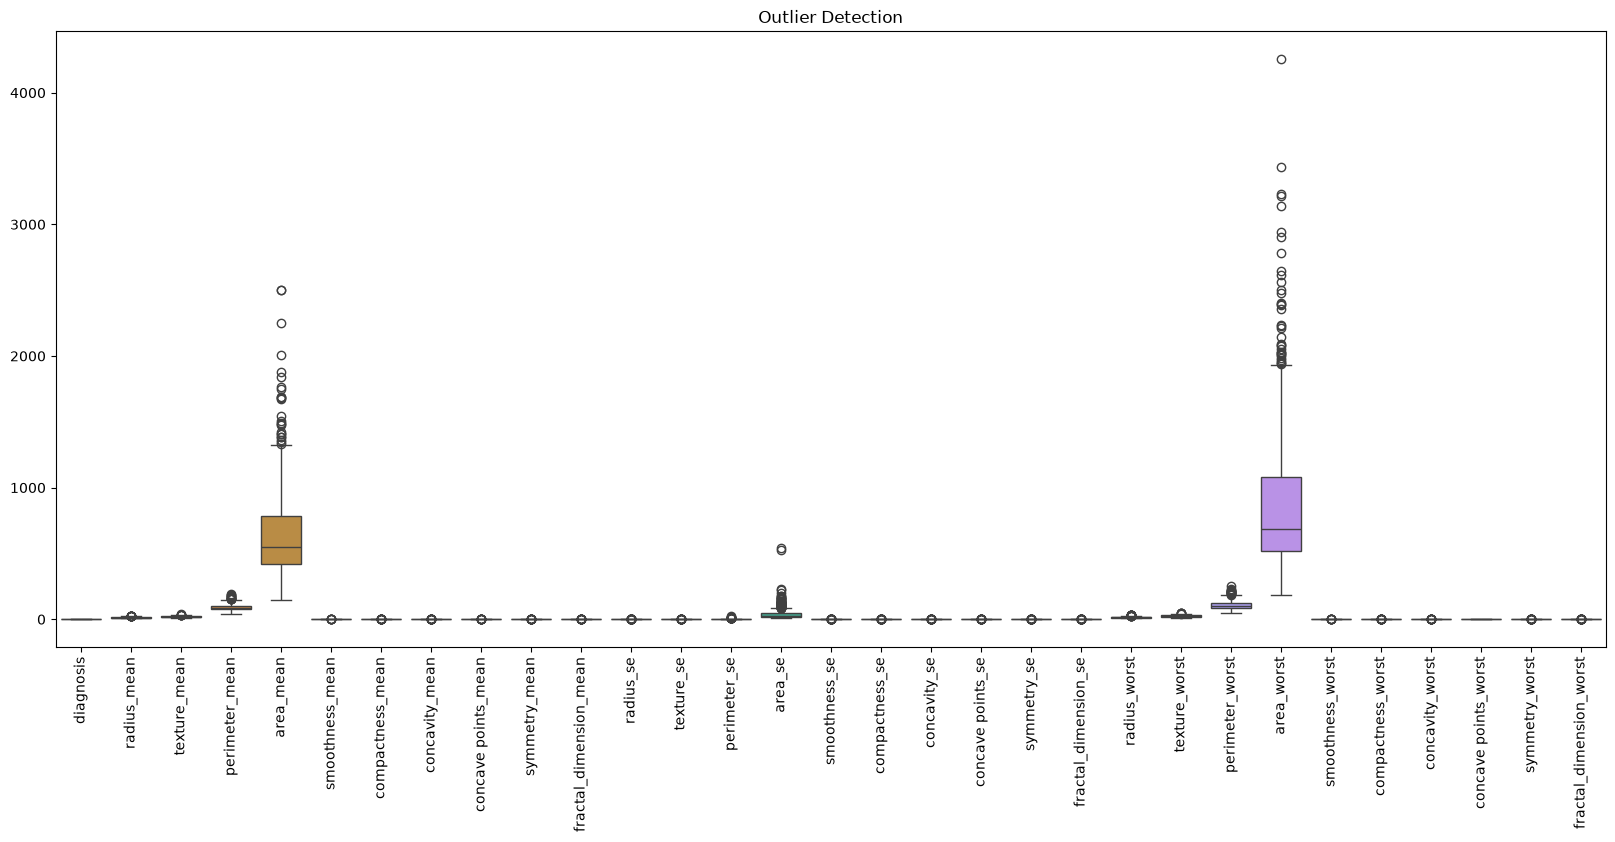

In [8]:
plt.figure(figsize=(20,8))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Outlier Detection")
plt.show()

In [9]:
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
def evaluate_model(model, X_test, y_test):

    pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    return accuracy, precision, recall, f1

In [13]:
baseline = DummyClassifier(strategy="most_frequent")

baseline.fit(X_train, y_train)

baseline_results = evaluate_model(
    baseline,
    X_test,
    y_test
)

d:\AI Internship\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [14]:
lr = LogisticRegression(max_iter=5000)

lr.fit(X_train_scaled, y_train)

lr_results = evaluate_model(
    lr,
    X_test_scaled,
    y_test
)


In [15]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

dt_results = evaluate_model(
    dt,
    X_test,
    y_test
)


In [16]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)

rf_results = evaluate_model(
    rf,
    X_test,
    y_test
)

In [17]:
knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(
    X_train_scaled,
    y_train
)

knn_results = evaluate_model(
    knn,
    X_test_scaled,
    y_test
)

In [18]:
svm = SVC(
    kernel='rbf',
    probability=True
)

svm.fit(
    X_train_scaled,
    y_train
)

svm_results = evaluate_model(
    svm,
    X_test_scaled,
    y_test
)


d:\AI Internship\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [19]:
results = pd.DataFrame({

'Model':[
'Baseline',
'Logistic Regression',
'Decision Tree',
'Random Forest',
'KNN',
'SVM'
],

'Accuracy':[
baseline_results[0],
lr_results[0],
dt_results[0],
rf_results[0],
knn_results[0],
svm_results[0]
],

'Precision':[
baseline_results[1],
lr_results[1],
dt_results[1],
rf_results[1],
knn_results[1],
svm_results[1]
],

'Recall':[
baseline_results[2],
lr_results[2],
dt_results[2],
rf_results[2],
knn_results[2],
svm_results[2]
],

'F1 Score':[
baseline_results[3],
lr_results[3],
dt_results[3],
rf_results[3],
knn_results[3],
svm_results[3]
]

})

print("\nMODEL COMPARISON")
print(results)



MODEL COMPARISON
                 Model  Accuracy  Precision    Recall  F1 Score
0             Baseline  0.631579   0.000000  0.000000  0.000000
1  Logistic Regression  0.964912   0.975000  0.928571  0.951220
2        Decision Tree  0.929825   0.904762  0.904762  0.904762
3        Random Forest  0.973684   1.000000  0.928571  0.962963
4                  KNN  0.956140   0.974359  0.904762  0.938272
5                  SVM  0.973684   1.000000  0.928571  0.962963


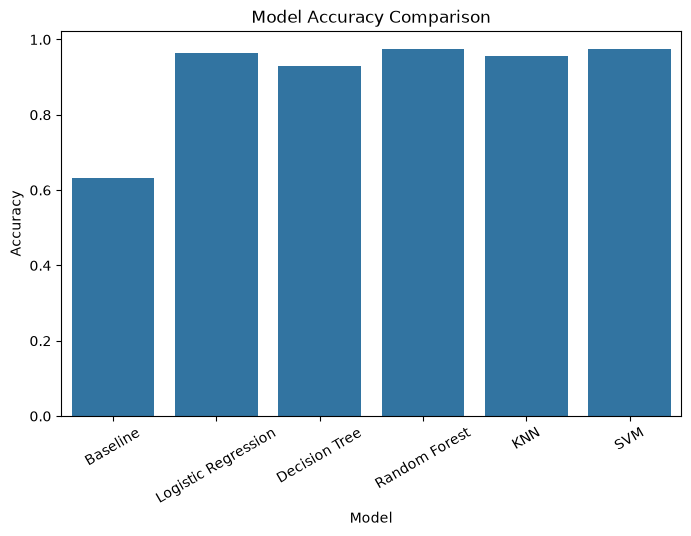

In [20]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results
)

plt.xticks(rotation=30)
plt.title("Model Accuracy Comparison")
plt.show()


In [21]:
best_model = rf

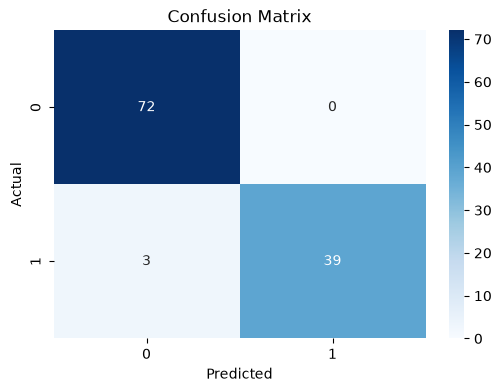

In [22]:
pred = best_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


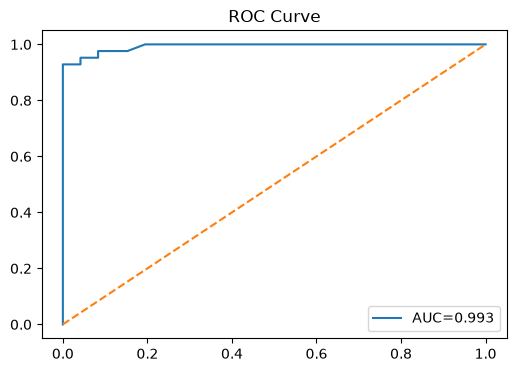

In [23]:
prob = best_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    prob
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(6,4))

plt.plot(
    fpr,
    tpr,
    label=f"AUC={roc_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.legend()

plt.title("ROC Curve")

plt.show()

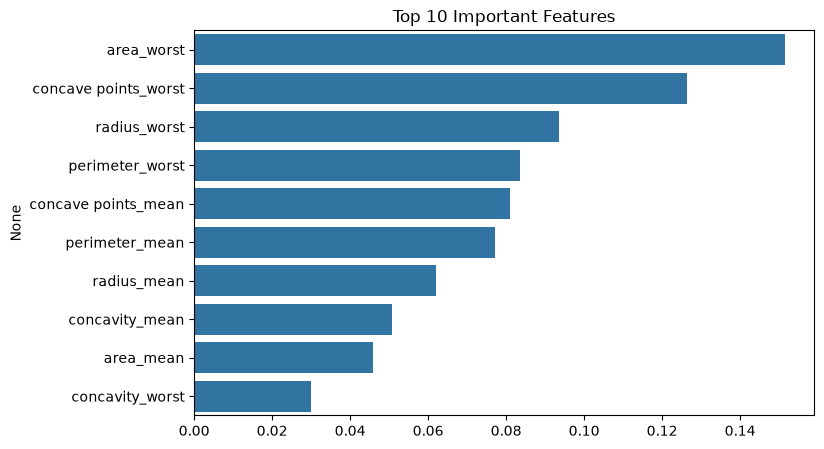

In [24]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

top_features = importance.sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    x=top_features.values,
    y=top_features.index
)

plt.title("Top 10 Important Features")
plt.show()


In [25]:
params = {

'n_estimators':[100,200,300],

'max_depth':[5,10,None],

'min_samples_split':[2,5,10]

}

grid = GridSearchCV(

    RandomForestClassifier(
        random_state=42
    ),

    params,

    cv=5,

    scoring='accuracy',

    n_jobs=-1

)

grid.fit(
    X_train,
    y_train
)

print("\nBest Parameters:")
print(grid.best_params_)

best_rf = grid.best_estimator_


Best Parameters:
{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}


In [26]:
cv_scores = cross_val_score(

    best_rf,

    X,

    y,

    cv=5,

    scoring='accuracy'

)

print("\nCross Validation Scores:")
print(cv_scores)

print("\nAverage CV Score:")
print(cv_scores.mean())



Cross Validation Scores:
[0.92105263 0.93859649 0.98245614 0.96491228 0.97345133]

Average CV Score:
0.9560937742586555


In [27]:
joblib.dump(
    best_rf,
    "breast_cancer_model.pkl"
)

print("\nModel Saved Successfully")



Model Saved Successfully


In [28]:
loaded_model = joblib.load(
    "breast_cancer_model.pkl"
)

sample_prediction = loaded_model.predict(
    X.iloc[:5]
)

print("\nSample Predictions:")
print(sample_prediction)


Sample Predictions:
[1 1 1 1 1]
